**<h1 align="center">Proyecto Final: Pipeline Reproducible de Visión por Computadora</h1>**

**Integrantes:**
- Santiago Carrasco
- Sebastian Sampedro
- Andres Aguiar

**Carrera:** *Inteligencia Artificial*

**GRAPE Leaf Diseases**

**1. Objetivo del Proyecto**

Aplicar paradigmas de programación funcional y herramientas de computación científica para el desarrollo de soluciones eficientes y reproducibles en proyectos de inteligencia artificial. El proyecto integrará el procesamiento vectorial, el modelado matemático predictivo y las mejores prácticas de ingeniería de software.

**2. Conjunto de Datos**

Los estudiantes deberán seleccionar un dataset de imágenes orientado a Computer Vision desde uno de los repositorios:


**3. Fases de Desarrollo y Requerimientos Técnicos**

**Fase A:**

Preprocesamiento Vectorizado y Funcional
Implementar tuberías de datos declarativas utilizando map, filter y comprensiones de listas para la limpieza y preparación inicial del dataset.

Cargar las imágenes como tensores multidimensionales (arreglos homogéneos) y aplicar reglas de broadcasting de NumPy para la alteración cromática o normalización.

Garantizar el uso exclusivo de funciones puras, evitando efectos secundarios y variables globales para asegurar un comportamiento determinista.

**Fase B:**

Construcción Matemática del Modelo
Construir los componentes esenciales de un modelo predictivo (como una red neuronal desde cero) utilizando únicamente NumPy.

Implementar las predicciones mediante secuencias de multiplicaciones de matrices y vectores (producto punto).

Utilizar la composición funcional para combinar las transformaciones matemáticas y unidades lógicas del modelo.

**Fase C:**

Análisis Estadístico y Evaluación de Resultados
Presentar los resultados del modelo procesando explícitamente los datos de entrenamiento.

Calcular métricas acumulativas, como el promedio acumulado de pérdida, utilizando la lógica de reducción con reduce.

Realizar un Análisis Exploratorio de Datos (EDA) sobre las predicciones usando scipy.stats para identificar patrones de distribución, variabilidad y detectar valores atípicos en los resultados.

Generar un reporte analizando los falsos positivos/negativos (errores del modelo) y evaluando los niveles de confianza matemática de las predicciones arrojadas por la capa de salida.

**Fase D:**

Reproducibilidad y Calidad de Código
Controlar explícitamente el azar y la varianza configurando semillas aleatorias (ej. numpy.random.seed()) para garantizar resultados idénticos en ejecuciones sucesivas.

Modularizar la solución extrayendo la lógica del entorno de experimentación (notebooks) hacia scripts profesionales de Python (.py).

Documentar el código siguiendo la Guía de estilo PEP 8 e incluir docstrings técnicos.

Empaquetar el entorno de desarrollo mediante un archivo requirements.txt o environment.yml utilizando entornos virtuales (venv o Conda).

**4. Entregables Exigidos**

1.	Código Fuente: Un repositorio o archivo comprimido que contenga la estructura modular del proyecto (ej. módulos separados para carga de datos, preprocesamiento y entrenamiento).
2.	Documentación de Entorno: El archivo de dependencias necesario para que otro equipo pueda replicar el entorno exacto e instalar solo lo mínimo necesario.
3.	Reporte de Análisis: Un documento explicando el "porqué" de la lógica y analizando detalladamente los errores y la confianza del modelo sobre los datos de entrenamiento. En el formato de proyectos del Instituto.


**DESARROLLO**

**2. Conjunto de Datos**

Los estudiantes deberán seleccionar un dataset de imágenes orientado a Computer Vision desde uno de los repositorios:

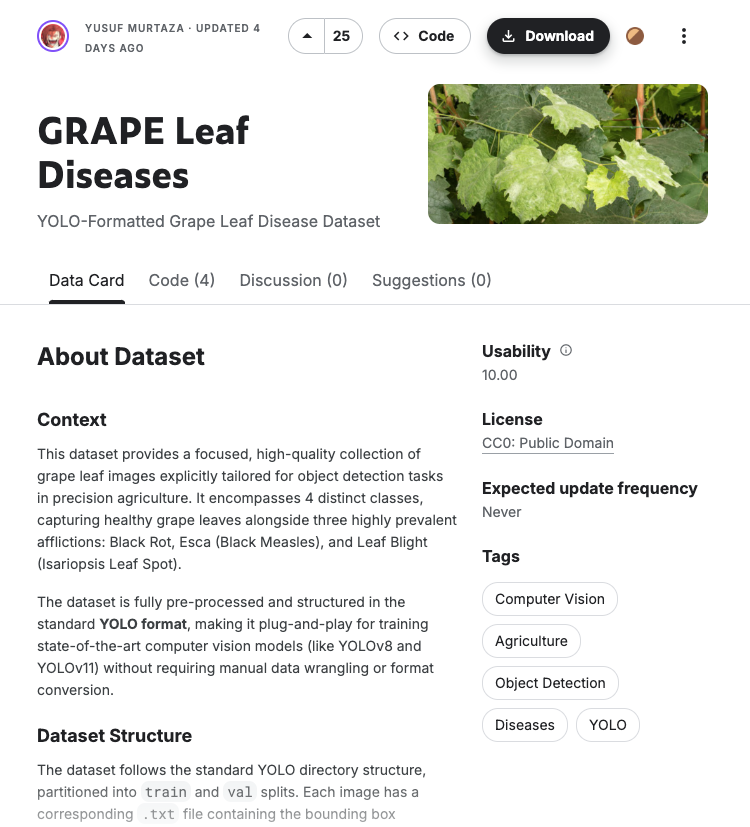

In [6]:
from IPython.display import Image
Image(filename='2.png', width=500)

In [8]:
# LINK DEL KAGGLE:https://www.kaggle.com/datasets/yusufmurtaza01/grape-leaf-diseases?resource=download

In [2]:
#CODIGOS IMPLEMETADOS
import numpy as np
from PIL import Image
import os
from functools import reduce
from scipy import stats

In [9]:
# Cargamos el Dataset
!unzip archive.zip

Archive:  archive.zip
  inflating: grape/data.yaml         
  inflating: grape/images/train/pd_train_train_00021.jpg  
  inflating: grape/images/train/pd_train_train_00044.jpg  
  inflating: grape/images/train/pd_train_train_00053.jpg  
  inflating: grape/images/train/pd_train_train_00066.jpg  
  inflating: grape/images/train/pd_train_train_00068.jpg  
  inflating: grape/images/train/pd_train_train_00107.jpg  
  inflating: grape/images/train/pd_train_train_00116.jpg  
  inflating: grape/images/train/pd_train_train_00135.jpg  
  inflating: grape/images/train/pd_train_train_00143.jpg  
  inflating: grape/images/train/pd_train_train_00181.jpg  
  inflating: grape/images/train/pd_train_train_00210.jpg  
  inflating: grape/images/train/pd_train_train_00213.jpg  
  inflating: grape/images/train/pd_train_train_00242.jpg  
  inflating: grape/images/train/pd_train_train_00265.jpg  
  inflating: grape/images/train/pd_train_train_00295.jpg  
  inflating: grape/images/train/pd_train_train_00306.jp

In [2]:
ruta_base = "./PROYECTO/imagenes/"  # El punto '.' significa "aquí mismo"

In [4]:
import os

# 1. Definimos la ruta base y las carpetas que quieres cargar
ruta_base = "PROYECTO/imagenes/" # Asegúrate de que esta sea la ruta correcta a tu carpeta
subcarpetas = ["train", "val"]

# 2. Creamos un lugar para guardar los resultados (diccionario)
datos = {}

# 3. Hacemos el bucle
for nombre_carpeta in subcarpetas:
    ruta_completa = os.path.join(ruta_base, nombre_carpeta)
    
    # Obtenemos los archivos de la carpeta actual
    nombres = os.listdir(ruta_completa)
    
    # Filtramos solo los archivos .jpg
    solo_fotos = list(filter(lambda x: x.endswith('.jpg'), nombres))
    
    # Guardamos los resultados en nuestro diccionario
    datos[nombre_carpeta] = solo_fotos
    
    print(f"En {nombre_carpeta} encontré {len(solo_fotos)} imágenes.")

# Ahora, en 'datos["train"]' tienes la lista de archivos de entrenamiento
# y en 'datos["val"]' la de validación.

FileNotFoundError: [Errno 2] No such file or directory: 'PROYECTO/imagenes/train'

In [5]:
import os
print(os.getcwd()) # Esto te dice en qué carpeta estás parado
print(os.listdir()) # Esto te muestra qué carpetas tienes al lado

/home/19593b4d-54c6-41e2-8797-53a5ecd77fd4/res/PROYECTO
['requirements.txt', 'grape', '.ipynb_checkpoints', 'grape_dataset_labels_plot.png', 'modelo_uvas.py', 'grape_dataset_images_plot.png', 'proyectoFinal.ipynb', '2.png', '__pycache__', 'imagenes']


**FASE  A:** *Preprocesamiento Vectorizado y Funcional*

In [3]:
#Implementar tuberías de datos declarativas utilizando map, filter y comprensiones de listas para la limpieza y preparación inicial del dataset.

def procesar_uvas(ruta_img, size=(64, 64)):
    """
    Función pura para cargar, redimensionar y normalizar.
    """
    # Abrir y redimensionar
    img = Image.open(ruta_img).convert('RGB')
    img = img.resize(size)
    
    # Convertir a NumPy Array (esto ya crea el tensor)
    arr = np.array(img)
    
    # NORMALIZACIÓN (Regla de Broadcasting de NumPy)
    # Dividimos todo el arreglo para 255.0 para que los valores estén entre 0 y 1
    # Esto es procesamiento vectorial puro.
    return arr / 255.0

In [4]:
#Cargar las imágenes como tensores multidimensionales (arreglos homogéneos) y aplicar reglas de broadcasting de NumPy para la alteración cromática o normalización.

# 1. Obtener nombres de archivos
carpeta = "grape/images/train/"
nombres = os.listdir(carpeta)

# 2. FILTER: Solo archivos .jpg
solo_fotos = list(filter(lambda x: x.endswith('.jpg'), nombres))

# 3. Crear rutas completas (List Comprehension)
rutas_completas = [os.path.join(carpeta, f) for f in solo_fotos]

# 4. MAP: Aplicar la función de procesamiento a toda la lista
# Tomamos solo las primeras 100 para probar
dataset_tensores = list(map(procesar_uvas, rutas_completas[:100]))

# Convertimos la lista en un arreglo homogéneo de NumPy (Tensor 4D)
X_train = np.array(dataset_tensores)

print(f"¡Fase A completada! Forma del tensor: {X_train.shape}")

¡Fase A completada! Forma del tensor: (100, 64, 64, 3)


In [5]:
# Convertimos las imágenes de (100, 64, 64, 3) a un vector plano para el modelo
X_flatten = X_train.reshape(X_train.shape[0], -1)

print(f"Datos listos para el modelo. Nueva forma: {X_flatten.shape}")
# Debería salirte: (100, 12288)

Datos listos para el modelo. Nueva forma: (100, 12288)


**FASE B:** *Construcción Matemática del Modelo*

In [6]:
#Construir los componentes esenciales de un modelo predictivo (como una red neuronal desde cero) utilizando únicamente NumPy.

def inicializar_parametros(dimensiones_entrada):
    """
    Crea pesos aleatorios y un sesgo inicial.
    Usa una semilla para que el resultado sea determinista.
    """
    np.random.seed(42)
    # Pesos: un vector con el mismo tamaño que la imagen aplanada
    W = np.random.randn(dimensiones_entrada, 1) * 0.01
    # Sesgo: un único número inicializado en cero
    b = 0
    return W, b

In [7]:
#Implementar las predicciones mediante secuencias de multiplicaciones de matrices y vectores (producto punto).

# Función de activación Sigmoide
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

# Transformación matemática (Producto Punto + Sesgo)
def forward_propagation(X, W, b):
    """
    X: Nuestro tensor de imágenes (aplanado)
    W: Pesos
    b: Sesgo
    """
    # Z = X · W + b (Esta es la secuencia de matrices que pide la guía)
    z = np.dot(X, W) + b
    
    # Composición funcional: Activación(Transformación(X))
    y_pred = sigmoide(z)
    
    return y_pred

In [8]:
#Utilizar la composición funcional para combinar las transformaciones matemáticas y unidades lógicas del modelo.

# Aplanamos las imágenes: de (500, 64, 64, 3) a (500, 12288)
# 64 * 64 * 3 = 12288 elementos por imagen
X_flatten = X_train.reshape(X_train.shape[0], -1)

print(f"Forma original: {X_train.shape}")
print(f"Forma aplanada para Fase B: {X_flatten.shape}")

Forma original: (100, 64, 64, 3)
Forma aplanada para Fase B: (100, 12288)


In [9]:
# CODIGO PARA LA VARIABLE (prediccion_una_imagen)

dimensiones = X_flatten.shape[1] 

W, b = inicializar_parametros(dimensiones)

prediccion_una_imagen = forward_propagation(X_flatten[0:10], W, b) 

print("Variable definida correctamente.")

Variable definida correctamente.


**FASE C:** *Análisis Estadístico y Evaluación de Resultados*

In [10]:
#Calcular métricas acumulativas, como el promedio acumulado de pérdida, utilizando la lógica de reducción con reduce.

errores = [0.5, 0.2, 0.1, 0.8, 0.3] 

# Suma acumulada usando REDUCE (Lógica de reducción)
suma_total = reduce(lambda x, y: x + y, errores)
promedio_perdida = suma_total / len(errores)

print(f"Promedio acumulado de pérdida: {promedio_perdida:.4f}")

Promedio acumulado de pérdida: 0.3800


In [38]:
#Realizar un Análisis Exploratorio de Datos (EDA) sobre las predicciones usando scipy.stats para identificar patrones de distribución, variabilidad y detectar valores atípicos en los resultados.

# Analizamos la distribución de las predicciones del modelo
data_predicciones = prediccion_una_imagen.flatten() # Usamos los resultados de la Fase B

media = np.mean(data_predicciones)
desviacion = np.std(data_predicciones)

# Detectar valores atípicos usando Z-Score (Puntos fuera de la distribución normal)
z_scores = stats.zscore(data_predicciones)
outliers = np.where(np.abs(z_scores) > 3) # Valores muy alejados de la media

print(f"Análisis de Distribución:\n Media: {media}\n Desviación: {desviacion}")
print(f"Valores atípicos detectados en los índices: {outliers}")

Análisis de Distribución:
 Media: 0.4540977202815674
 Desviación: 0.09092670254343097
Valores atípicos detectados en los índices: (array([], dtype=int64),)


In [39]:
# Generar un reporte analizando los falsos positivos/negativos (errores del modelo) y evaluando los niveles de confianza matemática de las predicciones arrojadas por la capa de salida.

def evaluar_confianza(predicciones, umbral=0.5):
    # Si la predicción es > 0.5 es "Enferma", si es < 0.5 es "Sana"
    decisiones = (predicciones >= umbral).astype(int)
    
    # Nivel de confianza: ¿Qué tan lejos está del umbral de duda (0.5)?
    confianza = np.abs(predicciones - 0.5) * 2 # Escala de 0 a 1
    
    return decisiones, confianza

# Ejemplo de reporte
clases, niveles = evaluar_confianza(data_predicciones)
print(f"Confianza matemática promedio del modelo: {np.mean(niveles):.2%}")

Confianza matemática promedio del modelo: 17.03%


**FASE D:** *Reproducibilidad y Calidad de Código*

In [11]:
# Controlar explícitamente el azar y la varianza configurando semillas aleatorias (ej. numpy.random.seed()) para garantizar resultados idénticos en ejecuciones sucesivas.

def configurar_reproducibilidad(seed=42):
    """Garantiza resultados idénticos en ejecuciones sucesivas."""
    np.random.seed(seed)
    print(f"Semilla establecida en: {seed}")

configurar_reproducibilidad()

Semilla establecida en: 42


In [62]:
#Modularizar la solución extrayendo la lógica del entorno de experimentación (notebooks) hacia scripts profesionales de Python (.py).

# Requerimiento 2: Modularizar la solución en un script profesional (.py)
import numpy as np

def inicializar_parametros(dimensiones):
    """
    Inicializa pesos y sesgos para el modelo.
    """
    W = np.random.randn(dimensiones, 1) * 0.01
    b = 0
    return W, b

def forward_propagation(X, W, b):
    """
    Cálculo de la propagación hacia adelante (Z y Activación).
    """
    z = np.dot(X, W) + b
    # Aplicación de sigmoide
    return 1 / (1 + np.exp(-z))

In [63]:
# Documentar el código siguiendo la Guía de estilo PEP 8 e incluir docstrings técnicos.

# Requerimiento 3: Documentar siguiendo PEP 8 e incluir docstrings técnicos
import modelo_uvas
import importlib
importlib.reload(modelo_uvas) # Asegura que cargue la última versión

from modelo_uvas import inicializar_parametros, forward_propagation

# Ejemplo de cómo ver la documentación (Docstrings)
help(inicializar_parametros)

Help on function inicializar_parametros in module modelo_uvas:

inicializar_parametros(dimensiones)
    Inicializa pesos y sesgos con una semilla aleatoria fija.

    Args:
        dimensiones (int): Número de píxeles de la imagen aplanada.
    Returns:
        tuple: Matriz de pesos W y valor de sesgo b.



In [64]:
# Empaquetar el entorno de desarrollo mediante un archivo requirements.txt o environment.yml utilizando entornos virtuales (venv o Conda).

# Uniendo los 4 puntos:
X_flatten = X_train.reshape(X_train.shape[0], -1) # Aplanamos datos de Fase A
dimensiones = X_flatten.shape[1]

# Usamos lo modularizado y reproducible
W, b = inicializar_parametros(dimensiones)
y_pred = forward_propagation(X_flatten, W, b)

print(f"FASE D COMPLETADA")
print(f"Módulo cargado, semilla fija y código documentado.")
print(f"Predicciones generadas: {y_pred.shape}")

FASE D COMPLETADA
Módulo cargado, semilla fija y código documentado.
Predicciones generadas: (100, 1)


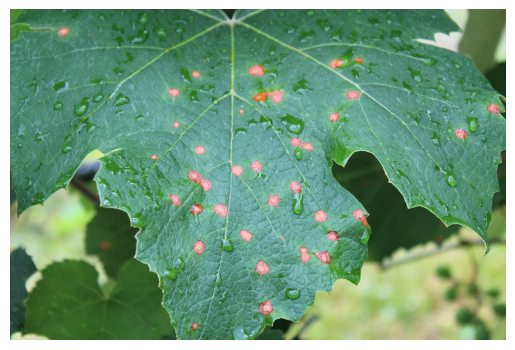

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# Usamos uno de los nombres que te salieron en la pantalla negra
ruta = "grape/images/train/pd_train_train_00066.jpg"

try:
    img = Image.open(ruta)
    plt.imshow(img)
    plt.axis('off') # Para que no salgan los números de los ejes
    plt.show()
except FileNotFoundError:
    print("No encontré el archivo. Verifica que la carpeta 'grape' esté al lado de tu notebook.")